# 04. 분석 질문과 가설 검증

[01 문제 정의와 가설](01_problem_hypothesis.md)에서 정의한 두 분석 질문과 세 가설을 검증한다. [02 데이터 전처리·ETL](02_data_preparation.ipynb)이 MySQL에 적재하고 [03 데이터 개요](03_data_overview.ipynb)에서 소개한 응답을 [최종 SQL](../sql/04_eda_validation.sql)로 조회한다. 분석 질문 1에서는 추천 의향과 지속 이용 의향·자기보고 구매 활동의 관계를, 분석 질문 2에서는 최초 인지 채널과 최근 구매 영향 채널의 연결을 확인한다. 이후 Q13·Q18로 반복되는 사용자 불편을 탐색한다.

---
## 1. 분석 대상과 분모

원본 269건에서 논리 모순 3건을 제외한 정제 응답은 266건이다. 가설 1·Q13은 플랫폼 사용자 200명, 가설 2는 그중 최근 6개월 구매자 191명, 가설 3은 공통 3채널 인지자 155명을 대상으로 한다. Q18은 유효 자유응답 전체 92건을 기준으로 보고, 그중 플랫폼 사용자 68건은 Q13과 연결할 때 함께 확인한다.

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'plotly_mimetype'
COLORS = {'positive': '#10B981', 'attention': '#EF4444',
          'view': '#3B82F6', 'cart': '#F59E0B', 'neutral': '#94A3B8'}

def find_project_root():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if ((candidate / 'notebooks').is_dir()
                and (candidate / 'sql').is_dir()
                and (candidate / 'data' / 'q18_audited_labels.csv').is_file()):
            return candidate
    raise FileNotFoundError(f'프로젝트 루트를 찾지 못했습니다: {start}')

ROOT = find_project_root()
load_dotenv(ROOT / '.env')
required = ('DB_USER', 'DB_PASSWORD', 'DB_HOST', 'DB_NAME')
missing = [key for key in required if not os.getenv(key)]
if missing:
    raise RuntimeError(f'MySQL 환경변수 누락: {", ".join(missing)}')
url = URL.create(
    'mysql+mysqlconnector', username=os.environ['DB_USER'],
    password=os.environ['DB_PASSWORD'], host=os.environ['DB_HOST'],
    database=os.environ['DB_NAME'],
)
engine = create_engine(url, pool_pre_ping=True)

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(ROOT / 'sql' / '04_eda_validation.sql')
def run(name):
    return pd.read_sql(Q[name], engine)

population = run('population').iloc[0]
users = run('users')
buyers = run('buyers')
# 여러 패션 플랫폼을 묻는 설문이므로 집단 라벨은 추천 의향 표현을 사용한다 (01과 같은 표기).
# SQL 뷰의 nps_segment 정의는 그대로 두고 조회 결과만 바꾼다.
SEGMENT_KO = {'Detractor': '비추천자', 'Passive': '중립', 'Promoter': '추천자'}
users['nps_segment'] = users['nps_segment'].map(SEGMENT_KO)
buyers['nps_segment'] = buyers['nps_segment'].map(SEGMENT_KO)
q13 = run('q13_base')
q13['selection'] = q13['dissatisfaction'].str.split(', ')
q13 = q13.explode('selection').drop(columns='dissatisfaction')
q13['selection'] = q13['selection'].str.strip()
q13 = q13.dropna(subset=['selection']).reset_index(drop=True)
q18 = run('q18_labeled')
q18_n = q18['user_id'].nunique()
q18_user = q18.loc[q18['is_platform_user'].eq(1)]
q18_user_n = q18_user['user_id'].nunique()
assert (len(users), len(buyers), q13['user_id'].nunique(), q18_n, q18_user_n) == (200, 191, 200, 92, 68)
assert int(population['h3_channel_n']) == 155
assert users[['nps', 'nps_segment', 'continue_score']].notna().all().all()
assert buyers[['frequency_score', 'recency_score']].notna().all().all()
display(pd.DataFrame([
    ['원본 설문', int(population['raw'])],
    ['논리 모순 제거 후', int(population['cleaned'])],
    ['플랫폼 사용자 · 가설 1/Q13', len(users)],
    ['최근 6개월 구매자 · 가설 2', len(buyers)],
    ['공통 3채널 인지자 · 가설 3', int(population['h3_channel_n'])],
    ['Q18 유효 자유응답 · 전체', q18_n],
    ['Q18 중 플랫폼 사용자 · 보조', q18_user_n],
], columns=['분석 대상', 'n']))

,분석 대상,n
0,원본 설문,269
1,논리 모순 제거 후,266
2,플랫폼 사용자 · 가설 1/Q13,200
3,최근 6개월 구매자 · 가설 2,191
4,공통 3채널 인지자 · 가설 3,155
5,Q18 유효 자유응답 · 전체,92
6,Q18 중 플랫폼 사용자 · 보조,68


---
## 2. 분석 질문 1 — 추천 의향은 지속 이용 의향 및 자기보고 구매 활동과 얼마나 일치하는가?

### 가설 1. 추천 의향과 지속 이용 의향

**가설:** 추천 의향이 높을수록 지속 이용 의향도 높을 것이다.

> **Q14.** 지금 가장 자주 사용하는 플랫폼을 앞으로도 계속 사용할 것 같나요? `5단계`  
> **Q15.** 현재 사용하는 패션 플랫폼을 지인에게 추천할 의향이 얼마나 있나요? `0–10점`

#### 분석 기준

Q15의 0–10점과 Q14의 5단계 의향을 비교한다. 긍정 지속 의향은 ‘아마 사용할 것 같다’ 또는 ‘계속 사용할 것 같다’다. NPS Score는 추천자 비율에서 비추천자 비율을 뺀 값이다.

In [2]:
segment_order = ['비추천자', '중립', '추천자']
cross = pd.crosstab(users['nps_segment'], users['is_retain_positive']).reindex(
    index=segment_order, columns=[0, 1], fill_value=0
)
cross.columns = ['그 외', '긍정 지속 의향']
cross.index.name = '추천 의향 집단'
cross['계'] = cross.sum(axis=1)
cross['긍정 비율(%)'] = (cross['긍정 지속 의향'] / cross['계'] * 100).round(1)

nps_score = (users['nps_segment'].eq('추천자').mean() - users['nps_segment'].eq('비추천자').mean()) * 100
positive_n = int(users['is_retain_positive'].sum())
detractor_positive = int(cross.loc['비추천자', '긍정 지속 의향'])
detractor_n = int(cross.loc['비추천자', '계'])
rho_h1, p_h1 = stats.spearmanr(users['nps'], users['continue_score'])
chi2_h1, p_chi_h1, _, expected_h1 = stats.chi2_contingency(cross[['그 외', '긍정 지속 의향']])
cramers_v_h1 = np.sqrt(chi2_h1 / len(users))
assert abs(nps_score - (-32.0)) < 0.0001
assert abs(rho_h1 - 0.4002) < 0.0001
assert abs(chi2_h1 - 9.5933) < 0.0001
assert abs(cramers_v_h1 - 0.2190) < 0.0001

print(f'NPS Score = {nps_score:.1f}')
print(f'긍정 지속 의향 = {positive_n}/{len(users)} ({positive_n/len(users):.1%})')
print(f'비추천자 긍정 지속 의향 = {detractor_positive}/{detractor_n} ({detractor_positive/detractor_n:.1%})')
print(f'Q15 × Q14: Spearman ρ={rho_h1:.3f}, p={p_h1:.4g}')
print(f'보조 교차표: χ²={chi2_h1:.3f}, p={p_chi_h1:.4f}, Cramér V={cramers_v_h1:.3f}; 기대빈도 <5 셀 {(expected_h1 < 5).sum()}개')
display(cross)

NPS Score = -32.0
긍정 지속 의향 = 187/200 (93.5%)
비추천자 긍정 지속 의향 = 77/88 (87.5%)
Q15 × Q14: Spearman ρ=0.400, p=4.335e-09
보조 교차표: χ²=9.593, p=0.0083, Cramér V=0.219; 기대빈도 <5 셀 1개


,그 외,긍정 지속 의향,계,긍정 비율(%)
추천 의향 집단,,,,
비추천자,11,77,88,87.5
중립,1,87,88,98.9
추천자,1,23,24,95.8


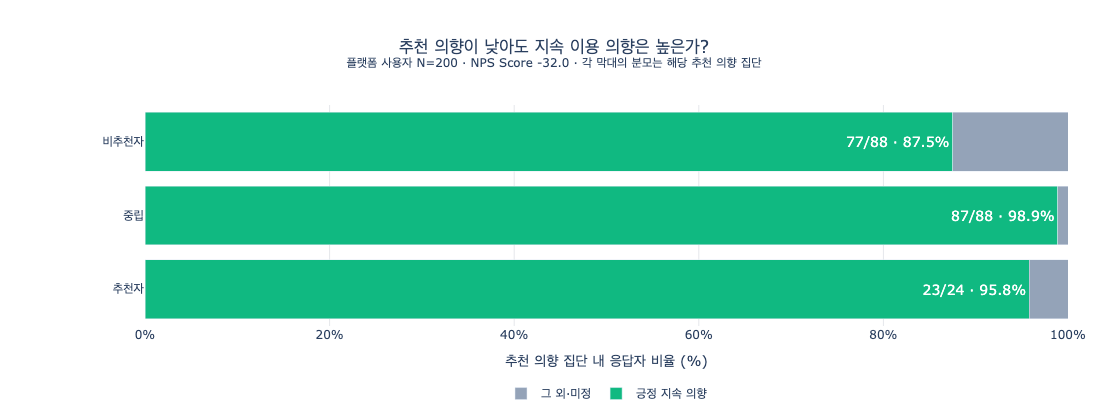

In [3]:
positive_pct = cross.loc[segment_order, '긍정 비율(%)']
other_pct = 100 - positive_pct
fig = go.Figure()
fig.add_trace(go.Bar(
    y=segment_order, x=positive_pct, orientation='h',
    name='긍정 지속 의향', marker_color=COLORS['positive'],
    text=[f"{int(cross.loc[s, '긍정 지속 의향'])}/{int(cross.loc[s, '계'])} · {positive_pct[s]:.1f}%" for s in segment_order],
    textposition='inside', textfont=dict(color='white', size=14),
    hovertemplate='%{y}<br>%{text}<extra></extra>',
))
fig.add_trace(go.Bar(
    y=segment_order, x=other_pct, orientation='h',
    name='그 외·미정', marker_color=COLORS['neutral'],
    hovertemplate='%{y}<br>그 외·미정 %{x:.1f}%<extra></extra>',
))
fig.update_layout(
    barmode='stack',
    title=dict(text=f'추천 의향이 낮아도 지속 이용 의향은 높은가?<br><sup>플랫폼 사용자 N={len(users)} · NPS Score {nps_score:.1f} · 각 막대의 분모는 해당 추천 의향 집단</sup>', x=0.5),
    xaxis=dict(title='추천 의향 집단 내 응답자 비율 (%)', range=[0, 100], gridcolor='#E5E7EB', ticksuffix='%'),
    yaxis=dict(autorange='reversed'),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(orientation='h', y=-0.24, x=0.5, xanchor='center'),
    height=420, width=1050, margin=dict(l=145, r=40, t=105, b=80),
)
fig.show()

추천 의향과 지속 이용 의향은 양의 관계를 보였다(Spearman ρ≈0.400). 플랫폼 사용자 200명의 NPS Score는 −32.0이었고, 187명(93.5%)이 긍정 지속 이용 의향을 답했다. 비추천자 88명 중에서도 77명(87.5%)이 긍정적으로 답했다. 병합 교차표의 카이제곱 검정은 χ²≈9.593, Cramér’s V≈.219였다.

#### 가설 1 결과

가설 1의 관계 방향은 지지됐다. 추천 의향이 높을수록 지속 이용 의향도 높아지는 경향(ρ≈0.400)이 나타났지만, 비추천자 88명 중 77명(87.5%)도 긍정 지속 의향을 답했다. 두 지표는 같은 방향으로 움직였고, 비추천자 집단에서도 긍정 지속 의향이 높게 나타났다.

#### 성별 세부 비교

플랫폼 사용자 200명을 남성·여성으로 나눠 같은 추천 의향 집단의 긍정 지속 이용 의향을 살펴본다. 전체 결과의 패턴을 성별 집단에서 살펴보는 세부 비교다.

,성별,추천 의향 집단,n/N · %
0,남성,비추천자,36/41 · 87.8%
1,남성,중립,32/32 · 100.0%
2,남성,추천자,6/6 · 100.0%
3,여성,비추천자,41/47 · 87.2%
4,여성,중립,55/56 · 98.2%
5,여성,추천자,17/18 · 94.4%


,성별,플랫폼 사용자 N,Spearman ρ
0,남성,79,0.325
1,여성,121,0.413


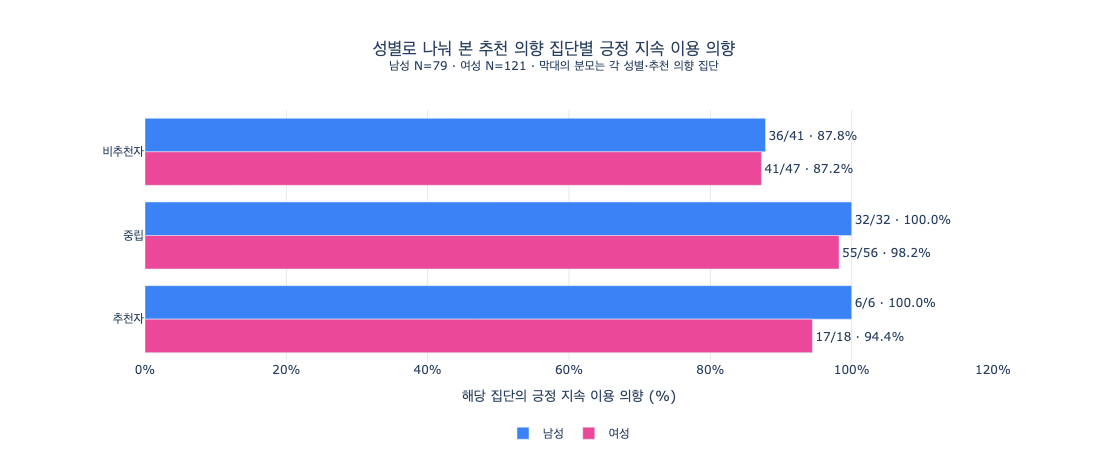

In [4]:
# 전체 분석에 사용한 SQL 뷰에서 성별과 채널 라벨만 연결한다.
gender_ref = pd.read_sql(
    'SELECT user_id, gender, discovery_label, influence_label FROM final_survey_semantic',
    engine,
)
assert gender_ref['user_id'].is_unique and len(gender_ref) == int(population['cleaned'])
assert gender_ref['gender'].value_counts().to_dict() == {'여성': 140, '남성': 126}
gender_key = gender_ref[['user_id', 'gender']]
users_gender = users.merge(gender_key, on='user_id', validate='one_to_one')
buyers_gender = buyers.merge(gender_key, on='user_id', validate='one_to_one')
q13_gender = q13.merge(gender_key, on='user_id', validate='many_to_one')
q18_gender = q18.merge(gender_key, on='user_id', validate='many_to_one')
GENDERS = ['남성', '여성']
GENDER_COLORS = {'남성': COLORS['view'], '여성': '#EC4899'}

def n_n_pct(n, denominator):
    return f'{int(n)}/{int(denominator)} · {n / denominator:.1%}'

assert len(users_gender) == len(users) == 200
assert len(buyers_gender) == len(buyers) == 191
assert q13_gender['user_id'].nunique() == 200
assert q18_gender['user_id'].nunique() == 92

h1_rows = []
rho_rows = []
for gender in GENDERS:
    subset = users_gender.loc[users_gender['gender'].eq(gender)]
    rho = stats.spearmanr(subset['nps'], subset['continue_score']).statistic
    rho_rows.append([gender, len(subset), rho])
    for segment in segment_order:
        group = subset.loc[subset['nps_segment'].eq(segment)]
        positive = int(group['is_retain_positive'].sum())
        denominator = len(group)
        assert denominator > 0
        h1_rows.append([gender, segment, positive, denominator,
                        positive / denominator * 100, n_n_pct(positive, denominator)])
h1_gender = pd.DataFrame(h1_rows, columns=['성별', '추천 의향 집단', '긍정 응답', '집단 N', '긍정률(%)', 'n/N · %'])
h1_rho_gender = pd.DataFrame(rho_rows, columns=['성별', '플랫폼 사용자 N', 'Spearman ρ'])
assert h1_gender['집단 N'].sum() == len(users)
assert h1_gender.groupby('추천 의향 집단')['긍정 응답'].sum().reindex(segment_order).tolist() == cross['긍정 지속 의향'].tolist()
display(h1_gender[['성별', '추천 의향 집단', 'n/N · %']])
display(h1_rho_gender.round({'Spearman ρ': 3}))

fig = go.Figure()
for gender in GENDERS:
    part = h1_gender.loc[h1_gender['성별'].eq(gender)].set_index('추천 의향 집단').reindex(segment_order)
    fig.add_trace(go.Bar(
        y=segment_order, x=part['긍정률(%)'], orientation='h', name=gender,
        marker_color=GENDER_COLORS[gender], text=part['n/N · %'], textposition='outside',
        customdata=part['n/N · %'],
        hovertemplate='%{y}<br>' + gender + ' %{customdata}<extra></extra>',
    ))
fig.update_layout(
    barmode='group',
    title=dict(text=f'성별로 나눠 본 추천 의향 집단별 긍정 지속 이용 의향<br><sup>남성 N={int(users_gender["gender"].eq("남성").sum())} · 여성 N={int(users_gender["gender"].eq("여성").sum())} · 막대의 분모는 각 성별·추천 의향 집단</sup>', x=0.5),
    xaxis=dict(title='해당 집단의 긍정 지속 이용 의향 (%)', range=[0, 120], gridcolor='#E5E7EB', ticksuffix='%'),
    yaxis=dict(autorange='reversed'),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.23),
    height=460, width=1050, margin=dict(l=145, r=115, t=110, b=85),
)
fig.show()

남녀 모두 비추천자 중 긍정 지속 이용 의향이 87%대였다. 남성 추천자 집단은 6명이다.

### 가설 2. 추천 의향과 자기보고 구매 활동

**가설:** 추천 의향이 높을수록 자기보고 구매 빈도는 높고 최근 구매 시점은 가까울 것이다.

> **Q9.** 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요? `순서형`  
> **Q10.** 패션 플랫폼에서 가장 최근에 구매한 시점은 언제인가요? `순서형`

#### 분석 기준

최근 6개월 구매자 191명의 Q9 빈도와 Q10 최근성을 순서점수로 비교한다. 최근성 점수가 높을수록 최근 구매 시점이 가깝다.

In [5]:
rho_f, p_f = stats.spearmanr(buyers['nps'], buyers['frequency_score'])
rho_r, p_r = stats.spearmanr(buyers['nps'], buyers['recency_score'])
results_h2 = pd.DataFrame([
    ['추천 의향 × 자기보고 구매 빈도(Q9)', len(buyers), rho_f, p_f],
    ['추천 의향 × 자기보고 구매 최근성(Q10)', len(buyers), rho_r, p_r],
], columns=['변수 쌍', 'n', 'Spearman ρ', '양측 p-value'])
assert abs(rho_f - 0.2480) < 0.0001
assert abs(rho_r - 0.1861) < 0.0001
display(results_h2.round({'Spearman ρ': 3, '양측 p-value': 4}))

,변수 쌍,n,Spearman ρ,양측 p-value
0,추천 의향 × 자기보고 구매 빈도(Q9),191,0.248,0.0005
1,추천 의향 × 자기보고 구매 최근성(Q10),191,0.186,0.0100


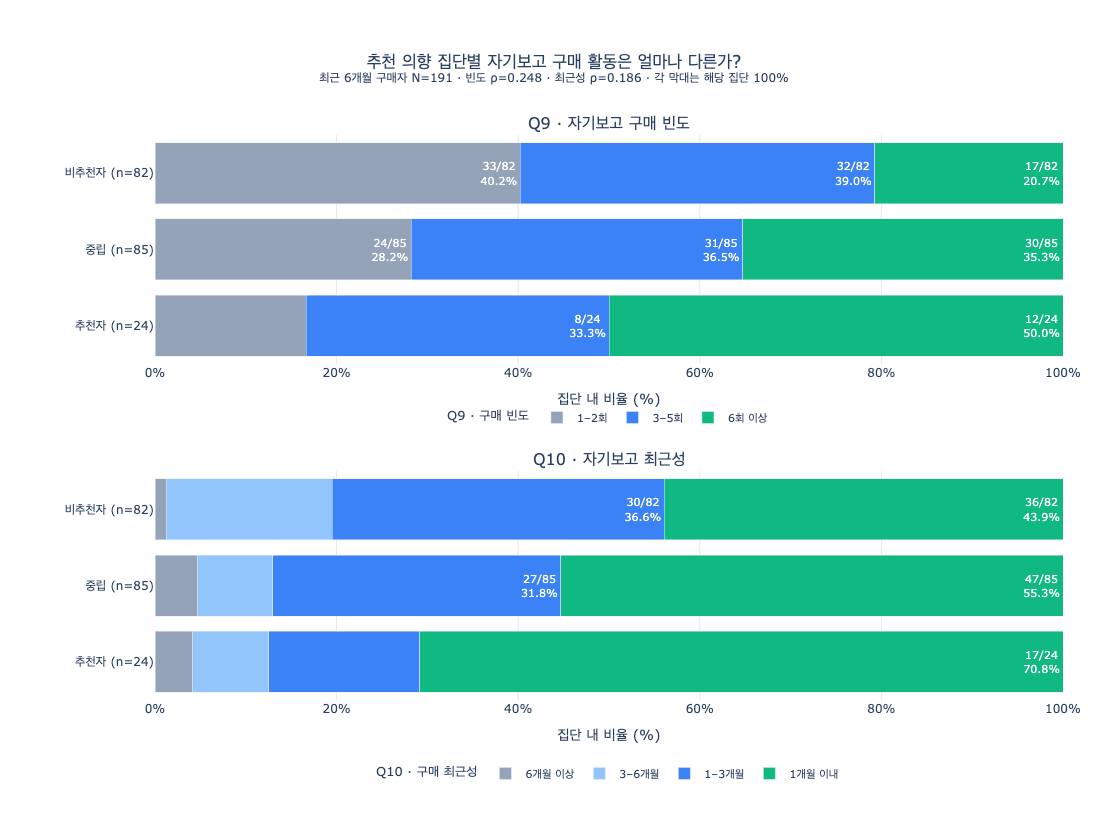

In [6]:
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Q9 · 자기보고 구매 빈도', 'Q10 · 자기보고 최근성'),
    vertical_spacing=0.19,
)
specs = [
    ('frequency_score', [1, 2, 3], ['1–2회', '3–5회', '6회 이상'],
     [COLORS['neutral'], COLORS['view'], COLORS['positive']]),
    ('recency_score', [1, 2, 3, 4], ['6개월 이상', '3–6개월', '1–3개월', '1개월 이내'],
     [COLORS['neutral'], '#93C5FD', COLORS['view'], COLORS['positive']]),
]
for row, (column, order, names, colors) in enumerate(specs, 1):
    table = pd.crosstab(buyers['nps_segment'], buyers[column]).reindex(
        index=segment_order, columns=order, fill_value=0
    )
    shares = table.div(table.sum(axis=1), axis=0).mul(100)
    for score, name, color in zip(order, names, colors):
        label = [
            f'{int(table.loc[segment, score])}/{int(table.loc[segment].sum())}<br>{shares.loc[segment, score]:.1f}%'
            for segment in segment_order
        ]
        fig.add_trace(go.Bar(
            y=segment_order, x=shares[score], orientation='h',
            marker_color=color, name=name, legendgroup=f'{column}-{score}',
            legend='legend' if row == 1 else 'legend2', showlegend=True,
            text=[t if shares.loc[segment, score] >= 19 else '' for segment, t in zip(segment_order, label)],
            textposition='inside', textfont=dict(color='white', size=11),
            customdata=label,
            hovertemplate='%{y}<br>%{customdata}<extra></extra>',
        ), row=row, col=1)
    fig.update_xaxes(title_text='집단 내 비율 (%)', range=[0, 100], gridcolor='#E5E7EB', ticksuffix='%', row=row, col=1)
    fig.update_yaxes(
        autorange='reversed', tickmode='array', tickvals=segment_order,
        ticktext=[f'{segment} (n={int(table.loc[segment].sum())})' for segment in segment_order],
        row=row, col=1,
    )
fig.update_layout(
    barmode='stack',
    title=dict(text=f'추천 의향 집단별 자기보고 구매 활동은 얼마나 다른가?<br><sup>최근 6개월 구매자 N={len(buyers)} · 빈도 ρ={rho_f:.3f} · 최근성 ρ={rho_r:.3f} · 각 막대는 해당 집단 100%</sup>', x=0.5),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(
        title='Q9 · 구매 빈도', orientation='h', x=0.5, xanchor='center',
        y=0.50, yanchor='middle', font=dict(size=11),
    ),
    legend2=dict(
        title='Q10 · 구매 최근성', orientation='h', x=0.5, xanchor='center',
        y=-0.13, yanchor='middle', font=dict(size=11),
    ),
    height=820, width=1000, margin=dict(l=155, r=45, t=135, b=120),
)
fig.show()

최근 6개월 구매자 191명에서 추천 의향은 자기보고 구매 빈도(ρ≈0.248)와 최근성(ρ≈0.186)에 모두 양의 관계를 보였다. 두 관계의 크기는 약했고, 추천 의향 집단 간 구매 응답 분포도 넓게 겹쳤다.

#### 가설 2 결과

가설 2는 방향상 지지됐다. 구매 빈도(ρ≈.248)와 최근성(ρ≈.186) 모두 추천 의향과 약한 양의 관계였고, 빈도 쪽 관계가 다소 컸다. 추천 의향 집단별 구매 응답 분포도 넓게 겹쳤다.

#### 성별 세부 비교

최근 6개월 구매자 안에서 성별별 추천 의향 집단의 구매 빈도와 최근성 분포를 전체 차트와 같은 범주로 비교한다.

,성별,최근 6개월 구매자 N,빈도 ρ,최근성 ρ
0,남성,73,0.300,0.297
1,여성,118,0.159,0.049


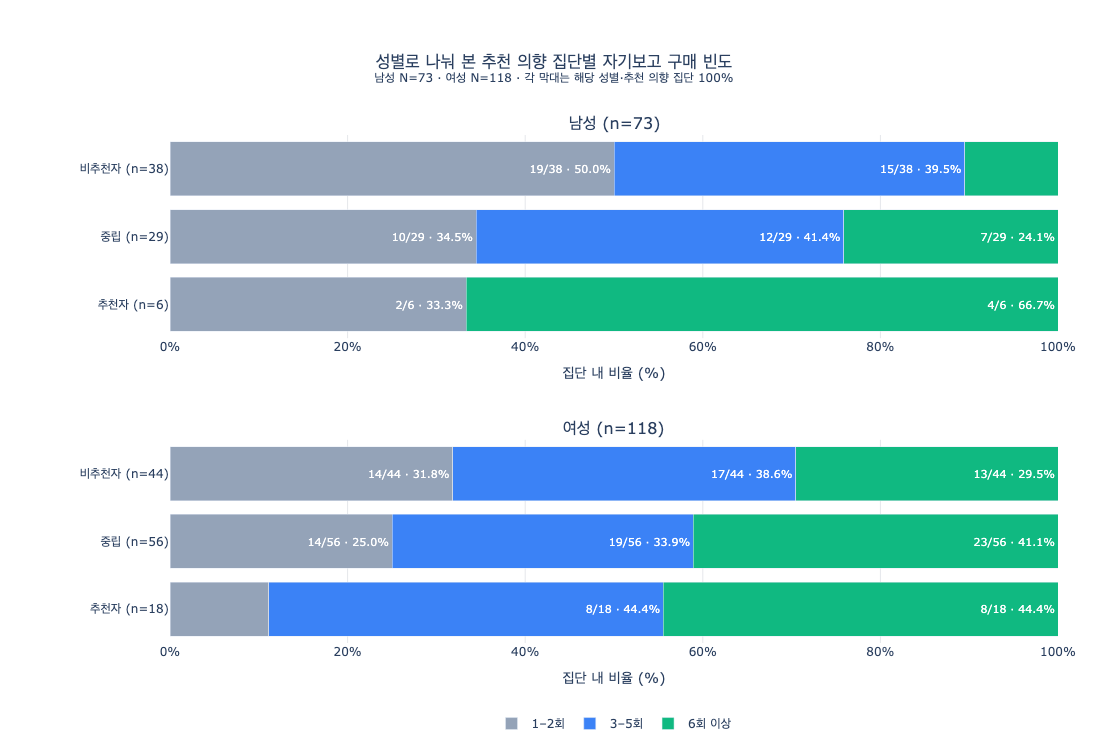

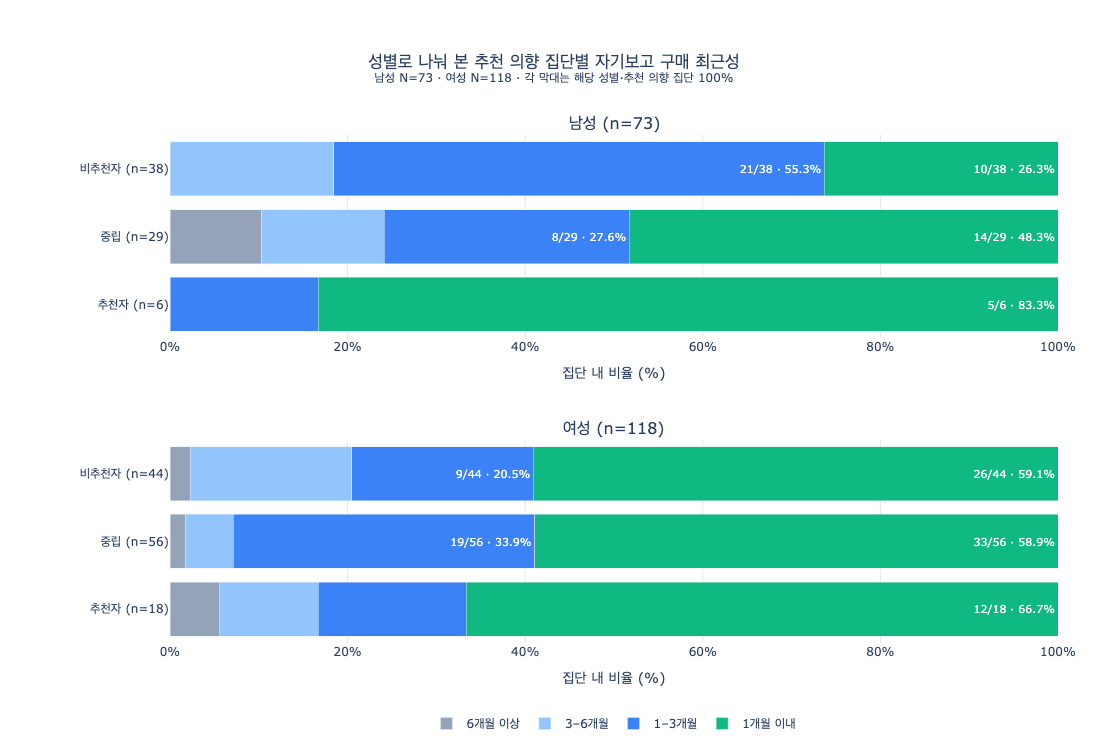

In [7]:
h2_rho_rows = []
for gender in GENDERS:
    subset = buyers_gender.loc[buyers_gender['gender'].eq(gender)]
    h2_rho_rows.append([
        gender, len(subset),
        stats.spearmanr(subset['nps'], subset['frequency_score']).statistic,
        stats.spearmanr(subset['nps'], subset['recency_score']).statistic,
    ])
h2_gender_rho = pd.DataFrame(h2_rho_rows, columns=['성별', '최근 6개월 구매자 N', '빈도 ρ', '최근성 ρ'])
assert h2_gender_rho['최근 6개월 구매자 N'].sum() == len(buyers)
display(h2_gender_rho.round({'빈도 ρ': 3, '최근성 ρ': 3}))

def show_h2_gender_distribution(column, order, names, colors, title):
    fig = make_subplots(rows=2, cols=1, subplot_titles=[f'{g} (n={len(buyers_gender.loc[buyers_gender.gender.eq(g)])})' for g in GENDERS], vertical_spacing=0.20)
    for row, gender in enumerate(GENDERS, 1):
        subset = buyers_gender.loc[buyers_gender['gender'].eq(gender)]
        table = pd.crosstab(subset['nps_segment'], subset[column]).reindex(
            index=segment_order, columns=order, fill_value=0,
        )
        assert int(table.to_numpy().sum()) == len(subset)
        shares = table.div(table.sum(axis=1), axis=0).mul(100)
        for score, name, color in zip(order, names, colors):
            labels = [n_n_pct(table.loc[s, score], table.loc[s].sum()) for s in segment_order]
            fig.add_trace(go.Bar(
                y=segment_order, x=shares[score], orientation='h',
                name=name, legendgroup=name, showlegend=(row == 1), marker_color=color,
                text=[label if shares.loc[s, score] >= 19 else '' for s, label in zip(segment_order, labels)],
                textposition='inside', textfont=dict(color='white', size=11),
                customdata=labels, hovertemplate='%{y}<br>%{customdata}<extra></extra>',
            ), row=row, col=1)
        fig.update_xaxes(title_text='집단 내 비율 (%)', range=[0, 100], gridcolor='#E5E7EB', ticksuffix='%', row=row, col=1)
        fig.update_yaxes(
            autorange='reversed', tickmode='array', tickvals=segment_order,
            ticktext=[f'{s} (n={int(table.loc[s].sum())})' for s in segment_order], row=row, col=1,
        )
    fig.update_layout(
        barmode='stack',
        title=dict(text=f'{title}<br><sup>남성 N={int(buyers_gender["gender"].eq("남성").sum())} · 여성 N={int(buyers_gender["gender"].eq("여성").sum())} · 각 막대는 해당 성별·추천 의향 집단 100%</sup>', x=0.5),
        paper_bgcolor='white', plot_bgcolor='white',
        legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.13),
        height=750, width=1050, margin=dict(l=170, r=50, t=135, b=100),
    )
    fig.show()

show_h2_gender_distribution(
    'frequency_score', [1, 2, 3], ['1–2회', '3–5회', '6회 이상'],
    [COLORS['neutral'], COLORS['view'], COLORS['positive']],
    '성별로 나눠 본 추천 의향 집단별 자기보고 구매 빈도',
)
show_h2_gender_distribution(
    'recency_score', [1, 2, 3, 4], ['6개월 이상', '3–6개월', '1–3개월', '1개월 이내'],
    [COLORS['neutral'], '#93C5FD', COLORS['view'], COLORS['positive']],
    '성별로 나눠 본 추천 의향 집단별 자기보고 구매 최근성',
)

이 표본의 성별 순위상관은 남성 빈도 ρ=.300·최근성 ρ=.297, 여성 빈도 ρ=.159·최근성 ρ=.049였다. 집단별 구매 응답 분포는 겹쳤다.

---
## 3. 분석 질문 2 — 최초 인지 채널은 최근 구매 영향 채널로도 이어지는가?

### 가설 3. 최초 인지 채널별 동일 채널 응답률

**가설:** 최초 인지 채널에 따라 같은 채널이 최근 구매에도 영향을 줬다고 응답한 비율은 다를 것이다.

Q16은 현재 이용하는 패션 앱을 **처음 알게 된 경로**, Q17은 **최근 6개월 내 구매에 가장 영향을 줬다고 답한 채널**이다. 두 문항에 공통으로 등장하는 SNS·유튜브·친구/지인으로 처음 인지한 플랫폼 사용자 155명을 대상으로 비교한다. 두 문항의 표준화 채널명이 같으면 ‘동일 채널’, 다르면 ‘다른 채널’로 구분한다. 카이제곱 검정은 최초 인지 채널과 동일 채널 응답 여부로 계산하며, 결과는 채널별 비율 차트로 보여준다.

가설 3 검정 결과: N=155, χ²=18.447, p=0.000099, Cramér V=0.345


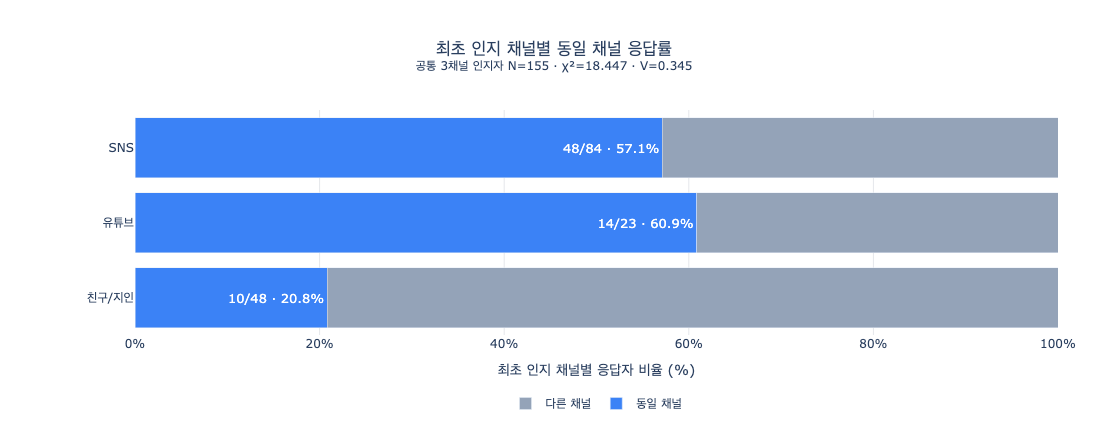

In [8]:
# 인지 채널별 동일 채널 응답률을 시각화하고 기존 카이제곱 검정을 유지한다.
COMMON_CH = ['SNS', '유튜브', '친구/지인']
channel_match_raw = run('channel_match')
cross_match = (
    channel_match_raw.set_index('인지채널')[['일치', '불일치']]
    .reindex(COMMON_CH).fillna(0).astype(int)
)
assert cross_match.to_dict('index') == {
    'SNS': {'일치':48, '불일치':36},
    '유튜브': {'일치':14, '불일치':9},
    '친구/지인': {'일치':10, '불일치':38},
}
channel_n = int(cross_match.to_numpy().sum())
assert channel_n == int(population['h3_channel_n']) == 155
channel_rates = (cross_match['일치'] / cross_match.sum(axis=1) * 100).round(1)
assert channel_rates.to_dict() == {'SNS':57.1, '유튜브':60.9, '친구/지인':20.8}
chi2_ch, p_ch, dof_ch, expected_ch = stats.chi2_contingency(cross_match)
cramer_v_ch = np.sqrt(chi2_ch / (channel_n * (min(cross_match.shape) - 1)))
assert dof_ch == 2 and (expected_ch < 5).sum() == 0
assert abs(chi2_ch - 18.4468) < 0.0001
assert abs(p_ch - 0.000099) < 0.000001
assert abs(cramer_v_ch - 0.3450) < 0.0001
channel_result = pd.DataFrame({
    '최초 인지 채널 (Q16)': COMMON_CH,
    '인지자 수': cross_match.sum(axis=1).to_numpy(),
    '동일 채널 응답': cross_match['일치'].to_numpy(),
    '동일 채널 비율 (%)': channel_rates.to_numpy(),
})
print(f'가설 3 검정 결과: N={channel_n}, χ²={chi2_ch:.3f}, p={p_ch:.6f}, Cramér V={cramer_v_ch:.3f}')

fig = go.Figure()
for name, color in [('동일 채널', COLORS['view']), ('다른 채널', COLORS['neutral'])]:
    counts = cross_match['일치' if name == '동일 채널' else '불일치']
    shares = counts / cross_match.sum(axis=1) * 100
    labels = [f'{int(counts[ch])}/{int(cross_match.loc[ch].sum())} · {shares[ch]:.1f}%'
              for ch in COMMON_CH]
    fig.add_trace(go.Bar(
        y=COMMON_CH, x=shares, orientation='h', name=name,
        marker_color=color, text=labels if name == '동일 채널' else None,
        textposition='inside' if name == '동일 채널' else None,
        textfont=dict(color='white', size=13), customdata=labels,
        hovertemplate='%{y}<br>' + name + ' %{customdata}<extra></extra>',
    ))
fig.update_layout(
    barmode='stack',
    title=dict(text=f'최초 인지 채널별 동일 채널 응답률<br><sup>공통 3채널 인지자 N={channel_n} · χ²={chi2_ch:.3f} · V={cramer_v_ch:.3f}</sup>', x=0.5),
    xaxis=dict(title='최초 인지 채널별 응답자 비율 (%)', range=[0, 100], gridcolor='#E5E7EB', ticksuffix='%'),
    yaxis=dict(autorange='reversed'),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.24),
    height=430, width=1000, margin=dict(l=135, r=50, t=110, b=85),
)
fig.show()

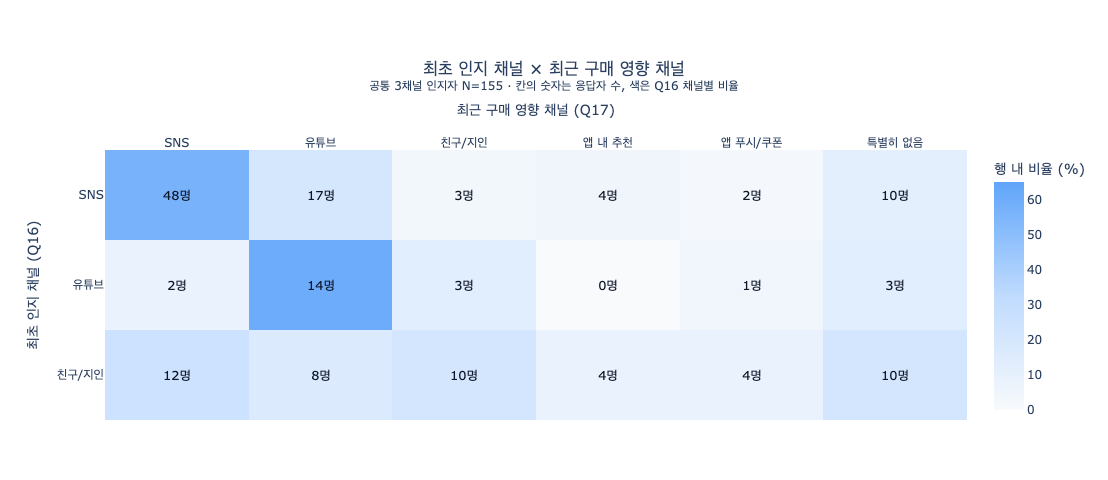

In [9]:
# 가설 3 대상 155명의 인지 × 구매 영향 채널 교차표를 표시한다.
INF_FULL = ['SNS', '유튜브', '친구/지인', '앱 내 추천', '앱 푸시/쿠폰', '특별히 없음']
cross_di = (
    run('channel_cross')
    .pivot(index='discovery', columns='influence', values='n')
    .reindex(index=COMMON_CH, columns=INF_FULL)
    .fillna(0).astype(int)
)
assert cross_di.to_dict('index') == {
    'SNS': {'SNS':48, '유튜브':17, '친구/지인':3, '앱 내 추천':4, '앱 푸시/쿠폰':2, '특별히 없음':10},
    '유튜브': {'SNS':2, '유튜브':14, '친구/지인':3, '앱 내 추천':0, '앱 푸시/쿠폰':1, '특별히 없음':3},
    '친구/지인': {'SNS':12, '유튜브':8, '친구/지인':10, '앱 내 추천':4, '앱 푸시/쿠폰':4, '특별히 없음':10},
}
assert int(cross_di.to_numpy().sum()) == channel_n
assert cross_di.sum(axis=1).to_dict() == cross_match.sum(axis=1).to_dict()
assert all(int(cross_di.loc[ch, ch]) == int(cross_match.loc[ch, '일치']) for ch in COMMON_CH)

# 칸은 응답자 수, 색은 최초 인지 채널(Q16)별 행 비율이다.
cross_di_pct = (cross_di.div(cross_di.sum(axis=1), axis=0) * 100).round(1)
fig = go.Figure(go.Heatmap(
    z=cross_di_pct.to_numpy(), x=INF_FULL, y=COMMON_CH,
    text=[[f'{int(n)}명' for n in row] for row in cross_di.to_numpy()],
    texttemplate='%{text}', textfont=dict(size=13, color='#0F172A'),
    colorscale=[[0, '#F8FAFC'], [0.5, '#BFDBFE'], [1, '#60A5FA']],
    zmin=0, zmax=65, colorbar=dict(title='행 내 비율 (%)'),
    hovertemplate='Q16 %{y} → Q17 %{x}<br>%{text}<br>행 내 비율 %{z:.1f}%<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'최초 인지 채널 × 최근 구매 영향 채널<br><sup>공통 3채널 인지자 N={channel_n} · 칸의 숫자는 응답자 수, 색은 Q16 채널별 비율</sup>', x=0.5),
    xaxis=dict(title='최근 구매 영향 채널 (Q17)', side='top'),
    yaxis=dict(title='최초 인지 채널 (Q16)', autorange='reversed'),
    plot_bgcolor='white', paper_bgcolor='white',
    height=480, width=1000, margin=dict(l=105, r=100, t=150, b=60),
)
fig.show()

같은 채널이 최근 구매에도 영향을 줬다고 응답한 비율은 유튜브 14/23명(60.9%), SNS 48/84명(57.1%), 친구/지인 10/48명(20.8%)이었다. 최초 인지 채널에 따라 동일 채널 응답률에 차이가 있었고, 카이제곱 검정에서도 확인됐다(χ²=18.447, p<.001, Cramér’s V=.345; 기대빈도 5 미만 셀 0개).

#### 가설 3 결과

가설 3은 지지됐다. SNS·유튜브 인지자는 절반 이상이 같은 채널을 최근 구매 영향 채널로도 답한 반면, 친구/지인 인지자는 20.8%였다. 즉 SNS·유튜브는 두 문항에서 다시 언급되는 비율이 상대적으로 높았고, 친구/지인은 최초 인지와 최근 구매 영향의 역할이 더 나뉘는 패턴을 보였다. 이 수치는 최초 인지와 최근 구매 영향에 대한 두 회상 응답의 연결을 보여준다.

#### 성별 세부 비교

전체 결과와 같은 공통 3채널 인지자 155명 안에서 채널별 동일 채널 응답률을 성별로 나눠 본다.

,성별,최초 인지 채널,n/N · %
0,남성,SNS,16/31 · 51.6%
1,남성,유튜브,10/15 · 66.7%
2,남성,친구/지인,5/17 · 29.4%
3,여성,SNS,32/53 · 60.4%
4,여성,유튜브,4/8 · 50.0%
5,여성,친구/지인,5/31 · 16.1%


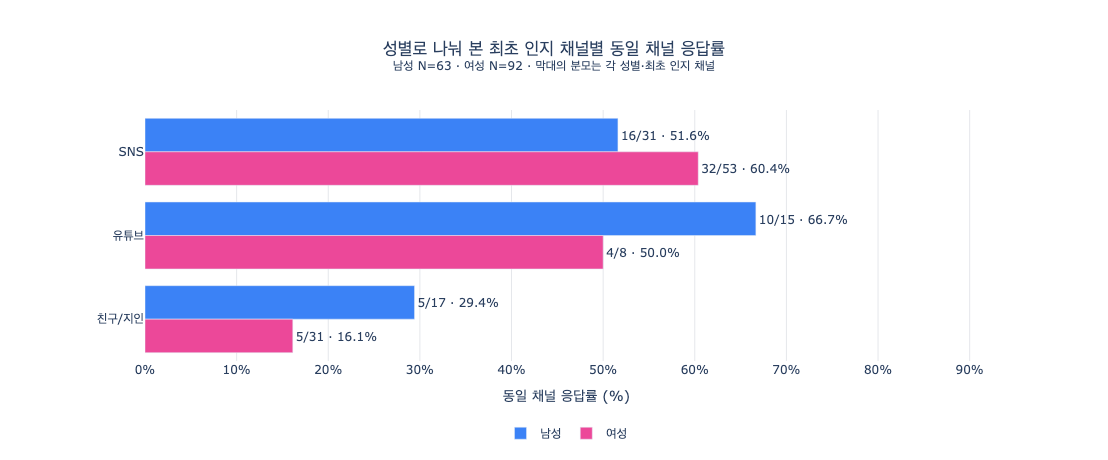

In [10]:
h3_gender_base = gender_ref.loc[
    gender_ref['user_id'].isin(users['user_id'])
    & gender_ref['discovery_label'].isin(COMMON_CH)
].copy()
assert len(h3_gender_base) == channel_n == 155
h3_rows = []
for gender in GENDERS:
    for channel in COMMON_CH:
        part = h3_gender_base.loc[
            h3_gender_base['gender'].eq(gender)
            & h3_gender_base['discovery_label'].eq(channel)
        ]
        matches = int(part['discovery_label'].eq(part['influence_label']).sum())
        denominator = len(part)
        assert denominator > 0
        h3_rows.append([gender, channel, matches, denominator,
                        matches / denominator * 100, n_n_pct(matches, denominator)])
h3_gender = pd.DataFrame(h3_rows, columns=['성별', '최초 인지 채널', '동일 채널', '채널 N', '응답률(%)', 'n/N · %'])
assert h3_gender['채널 N'].sum() == channel_n
assert h3_gender.groupby('최초 인지 채널')['동일 채널'].sum().reindex(COMMON_CH).tolist() == cross_match['일치'].tolist()
display(h3_gender[['성별', '최초 인지 채널', 'n/N · %']])

fig = go.Figure()
for gender in GENDERS:
    part = h3_gender.loc[h3_gender['성별'].eq(gender)].set_index('최초 인지 채널').reindex(COMMON_CH)
    fig.add_trace(go.Bar(
        y=COMMON_CH, x=part['응답률(%)'], orientation='h', name=gender,
        marker_color=GENDER_COLORS[gender], text=part['n/N · %'], textposition='outside',
        customdata=part['n/N · %'],
        hovertemplate='%{y}<br>' + gender + ' %{customdata}<extra></extra>',
    ))
fig.update_layout(
    barmode='group',
    title=dict(text=f'성별로 나눠 본 최초 인지 채널별 동일 채널 응답률<br><sup>남성 N={int(h3_gender_base["gender"].eq("남성").sum())} · 여성 N={int(h3_gender_base["gender"].eq("여성").sum())} · 막대의 분모는 각 성별·최초 인지 채널</sup>', x=0.5),
    xaxis=dict(title='동일 채널 응답률 (%)', range=[0, 92], gridcolor='#E5E7EB', ticksuffix='%'),
    yaxis=dict(autorange='reversed'),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.23),
    height=460, width=1050, margin=dict(l=145, r=120, t=110, b=85),
)
fig.show()

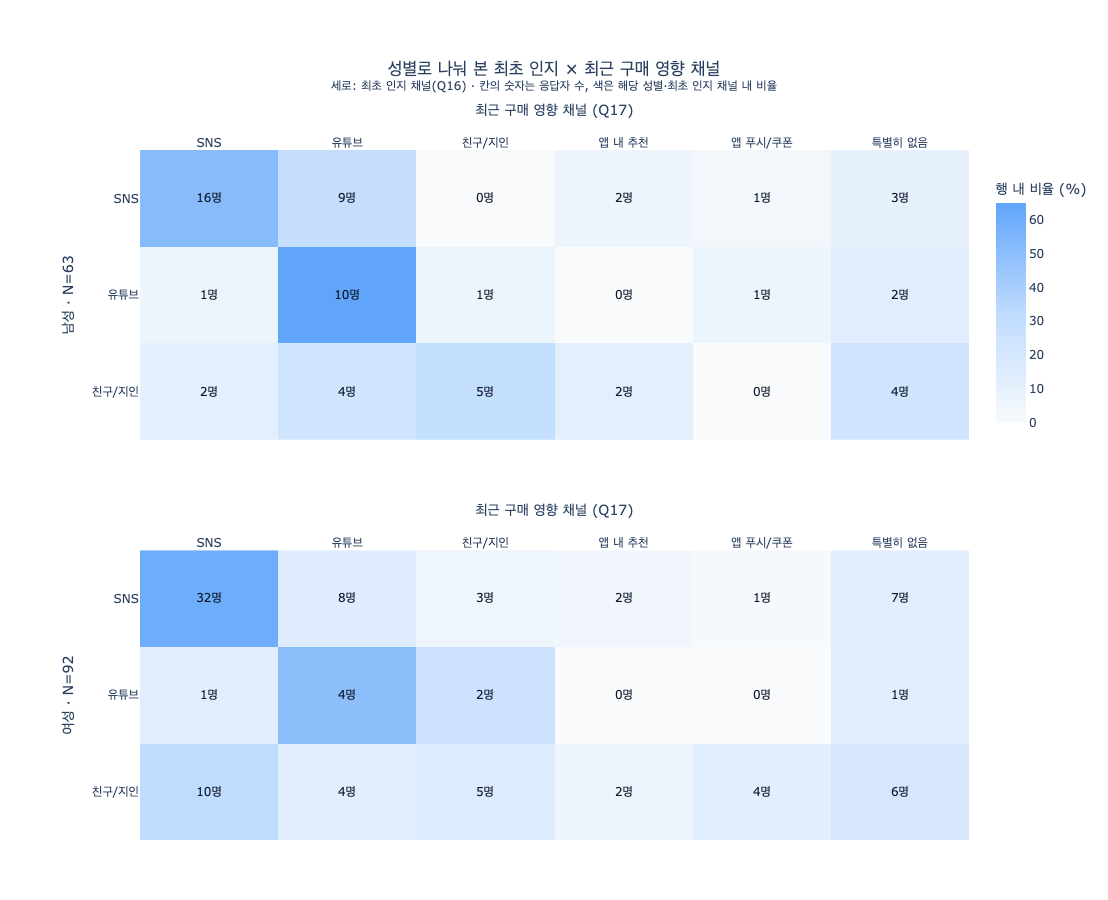

In [11]:
# 전체 히트맵과 같은 정의로 성별 채널 연결을 한 열에 세로로 비교한다.
gender_cross = {}
for gender in GENDERS:
    part = h3_gender_base.loc[h3_gender_base['gender'].eq(gender)]
    table = pd.crosstab(part['discovery_label'], part['influence_label']).reindex(
        index=COMMON_CH, columns=INF_FULL, fill_value=0,
    )
    assert int(table.to_numpy().sum()) == len(part)
    expected_matches = (h3_gender.loc[h3_gender['성별'].eq(gender)]
                        .set_index('최초 인지 채널')['동일 채널'].reindex(COMMON_CH))
    assert all(int(table.loc[ch, ch]) == int(expected_matches[ch]) for ch in COMMON_CH)
    gender_cross[gender] = table
assert sum(gender_cross.values()).equals(cross_di)

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.16,
)
for row, gender in enumerate(GENDERS, 1):
    table = gender_cross[gender]
    percentages = table.div(table.sum(axis=1), axis=0).mul(100).round(1)
    fig.add_trace(go.Heatmap(
        z=percentages.to_numpy(), x=INF_FULL, y=COMMON_CH,
        text=[[f'{int(n)}명' for n in counts] for counts in table.to_numpy()],
        texttemplate='%{text}', textfont=dict(size=12, color='#0F172A'),
        colorscale=[[0, '#F8FAFC'], [0.5, '#BFDBFE'], [1, '#60A5FA']],
        zmin=0, zmax=65, showscale=(row == 1),
        colorbar=dict(title='행 내 비율 (%)', len=0.38, y=0.78) if row == 1 else None,
        hovertemplate=gender + ' · Q16 %{y} → Q17 %{x}<br>%{text}<br>행 내 비율 %{z:.1f}%<extra></extra>',
    ), row=row, col=1)
    fig.update_xaxes(title_text='최근 구매 영향 채널 (Q17)', side='top', row=row, col=1)
    fig.update_yaxes(title_text=f'{gender} · N={int(table.to_numpy().sum())}', autorange='reversed', row=row, col=1)
fig.update_layout(
    title=dict(text='성별로 나눠 본 최초 인지 × 최근 구매 영향 채널<br><sup>세로: 최초 인지 채널(Q16) · 칸의 숫자는 응답자 수, 색은 해당 성별·최초 인지 채널 내 비율</sup>', x=0.5),
    paper_bgcolor='white', plot_bgcolor='white',
    height=900, width=1000, margin=dict(l=140, r=100, t=150, b=60),
)
fig.show()

남녀 모두 친구/지인의 동일 채널 응답률이 SNS·유튜브보다 낮았다. 여성 유튜브 인지자는 8명으로, 이 비율은 작은 집단의 탐색 결과로 읽는다.

---
## 4. 세 가설의 핵심 결과

### 가설 1 · 추천 의향과 지속 이용 의향

두 변수는 양의 관계(ρ≈0.400)였지만, 비추천자 77/88명(87.5%)도 긍정 지속 의향을 답했다. 성별 비추천자 긍정률은 남성 87.8%, 여성 87.2%로 비슷했다.

### 가설 2 · 추천 의향과 자기보고 구매 활동

추천 의향과 구매 빈도(ρ≈.248)·최근성(ρ≈.186)의 관계는 모두 약했다. 성별 표본의 순위상관은 남성 빈도 .300·최근성 .297, 여성 빈도 .159·최근성 .049였다.

### 가설 3 · 최초 인지 채널과 최근 구매 영향 채널

동일 채널 응답률은 유튜브 60.9%, SNS 57.1%, 친구/지인 20.8%였다. 친구/지인은 남성 29.4%, 여성 16.1%로 두 집단에서 가장 낮았다. 여성 유튜브 인지자 집단은 8명이다.

추천 의향·지속 이용 의향·자기보고 구매 활동의 연결 정도와 채널별 응답 패턴을 구분해 살펴볼 필요가 있다.

---
## 5. 후속 탐색 — 어떤 불편이 반복적으로 나타났는가?

세 가설을 확인한 뒤 선택형 Q13과 자유응답 Q18에서 반복된 불편을 살펴본다. 이 탐색은 다음에 확인할 UX 후보를 찾는 과정이다.

- **Q13:** 플랫폼 사용자 200명의 복수 선택 응답.
- **Q18 전체:** 정제 응답 중 자발적으로 남긴 유효 자유응답 92건. 전수 검토 후 확정한 다중 라벨 CSV(`data/q18_audited_labels.csv`)를 사용하며 한 응답에 여러 유형을 붙일 수 있다.
- **Q18 플랫폼 사용자:** 전체 92건 중 68건. Q13과 사용자 집단을 맞춰 볼 때 함께 확인한다.

In [12]:
# Q13: 플랫폼 사용자 200명 중 각 선택지를 고른 응답자 수
q13_counts = q13.groupby('selection')['user_id'].nunique().sort_values(ascending=False)
assert q13_counts.to_dict() == {
    '사이즈 문제': 102, '실제 상품이 사진과 달랐음': 88, '배송이 느렸음': 48,
    '반품 / 교환 과정이 불편했음': 45, '불만족 경험 없음': 26,
}
q13_table = q13_counts.rename('선택 응답자').to_frame()
q13_table['선택률 (%)'] = (q13_table['선택 응답자'] / len(users) * 100).round(1)
q13_table.index.name = 'Q13 선택지'
assert q13_table.loc['사이즈 문제', '선택률 (%)'] == 51.0

# Q18: 유효 자유응답 전체 92건을 기준으로 다중 라벨을 집계
q18_types = q18.groupby('category')['user_id'].nunique().sort_values(ascending=False)
assert q18_types.to_dict() == {
    '사이즈/핏': 39, '추천/검색': 24, '정보/리뷰': 21, '가격/혜택': 14,
    'UI/UX': 12, '재고/품질': 8, '배송/반품': 7, '광고/마케팅': 5,
}
q18_table = q18_types.rename('언급 응답자').to_frame()
q18_table['언급률 (%)'] = (q18_table['언급 응답자'] / q18_n * 100).round(1)
q18_table.index.name = 'Q18 언급 유형'
assert q18_table.loc['사이즈/핏', '언급률 (%)'] == 42.4

# Q13과 플랫폼 사용자 집단을 맞춰 볼 때 68건 subset을 사용
q18_user_types = q18_user.groupby('category')['user_id'].nunique().sort_values(ascending=False)
assert q18_user_types['사이즈/핏'] == 28
q18_user_size_pct = round(q18_user_types['사이즈/핏'] / q18_user_n * 100, 1)
assert q18_user_size_pct == 41.2

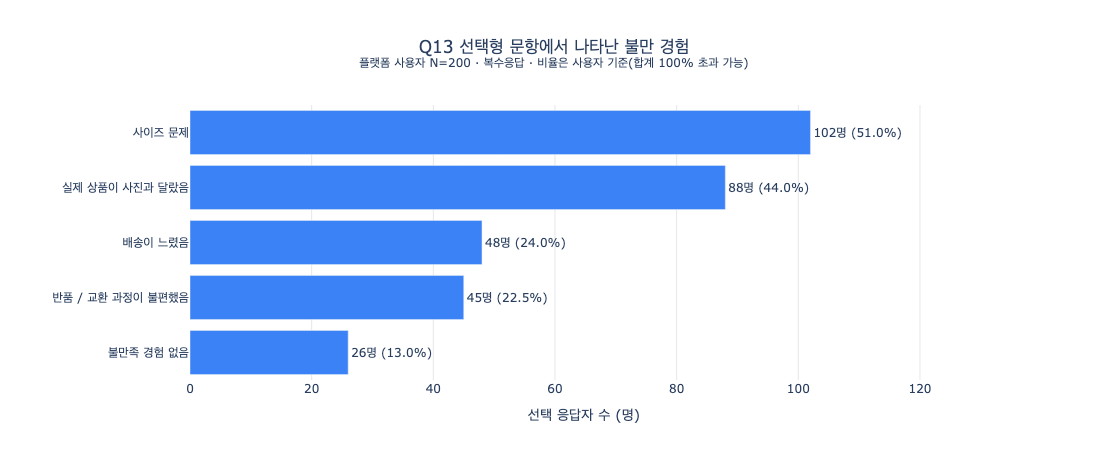

In [13]:
# Q13 선택형 복수응답: 플랫폼 사용자 200명을 분모로 응답 수와 선택률 표시
fig = go.Figure(go.Bar(
    x=q13_table['선택 응답자'].to_numpy(),
    y=q13_table.index.tolist(),
    orientation='h',
    marker_color=COLORS['view'],
    text=[f'{int(count)}명 ({pct:.1f}%)' for count, pct in
          zip(q13_table['선택 응답자'], q13_table['선택률 (%)'])],
    textposition='outside',
    cliponaxis=False,
    hovertemplate='%{y}<br>%{text}<extra></extra>',
))
fig.update_xaxes(title_text='선택 응답자 수 (명)',
                 range=[0, q13_table['선택 응답자'].max() * 1.27], gridcolor='#E5E7EB')
fig.update_yaxes(autorange='reversed')
fig.update_layout(
    title=dict(text=f'Q13 선택형 문항에서 나타난 불만 경험<br><sup>플랫폼 사용자 N={len(users)} · 복수응답 · 비율은 사용자 기준(합계 100% 초과 가능)</sup>', x=0.5),
    paper_bgcolor='white', plot_bgcolor='white',
    height=450, width=1000, margin=dict(l=190, r=130, t=105, b=70),
    showlegend=False,
)
fig.show()

### 성별 세부 비교 · Q13

각 선택지를 고른 사람을 해당 성별 플랫폼 사용자 수로 나눈다. 한 사람이 여러 항목을 고를 수 있어 성별별 선택률 합계도 100%를 넘을 수 있다.

,성별,Q13 선택지,n/N · %
0,남성,사이즈 문제,37/79 · 46.8%
1,남성,실제 상품이 사진과 달랐음,25/79 · 31.6%
2,남성,배송이 느렸음,14/79 · 17.7%
3,남성,반품 / 교환 과정이 불편했음,19/79 · 24.1%
4,남성,불만족 경험 없음,16/79 · 20.3%
5,여성,사이즈 문제,65/121 · 53.7%
6,여성,실제 상품이 사진과 달랐음,63/121 · 52.1%
7,여성,배송이 느렸음,34/121 · 28.1%
8,여성,반품 / 교환 과정이 불편했음,26/121 · 21.5%
9,여성,불만족 경험 없음,10/121 · 8.3%


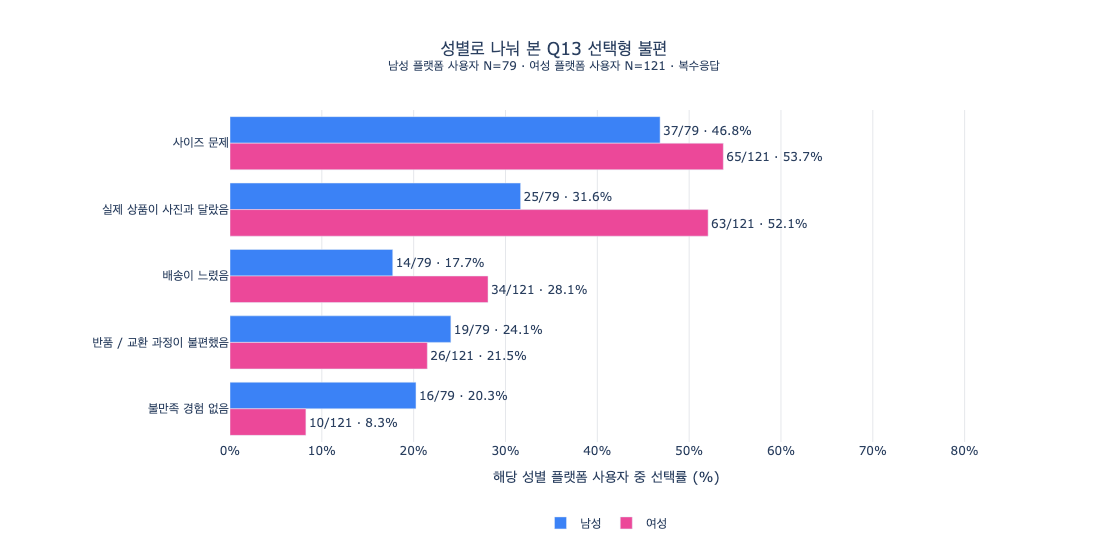

In [14]:
q13_gender_n = users_gender.groupby('gender')['user_id'].nunique().reindex(GENDERS)
q13_categories = q13_table.index.tolist()
q13_rows = []
for gender in GENDERS:
    denominator = int(q13_gender_n[gender])
    for category in q13_categories:
        selected = q13_gender.loc[
            q13_gender['gender'].eq(gender)
            & q13_gender['selection'].eq(category), 'user_id'
        ].nunique()
        q13_rows.append([gender, category, selected, denominator,
                         selected / denominator * 100, n_n_pct(selected, denominator)])
q13_gender_table = pd.DataFrame(q13_rows, columns=['성별', 'Q13 선택지', '선택자', '성별 N', '선택률(%)', 'n/N · %'])
assert q13_gender_table.groupby('Q13 선택지')['선택자'].sum().reindex(q13_categories).tolist() == q13_counts.reindex(q13_categories).tolist()
display(q13_gender_table[['성별', 'Q13 선택지', 'n/N · %']])

fig = go.Figure()
for gender in GENDERS:
    part = q13_gender_table.loc[q13_gender_table['성별'].eq(gender)].set_index('Q13 선택지').reindex(q13_categories)
    fig.add_trace(go.Bar(
        y=q13_categories, x=part['선택률(%)'], orientation='h', name=gender,
        marker_color=GENDER_COLORS[gender], text=part['n/N · %'], textposition='outside',
        customdata=part['n/N · %'],
        hovertemplate='%{y}<br>' + gender + ' %{customdata}<extra></extra>',
    ))
fig.update_layout(
    barmode='group',
    title=dict(text=f'성별로 나눠 본 Q13 선택형 불편<br><sup>남성 플랫폼 사용자 N={int(q13_gender_n["남성"])} · 여성 플랫폼 사용자 N={int(q13_gender_n["여성"])} · 복수응답</sup>', x=0.5),
    xaxis=dict(title='해당 성별 플랫폼 사용자 중 선택률 (%)', range=[0, 82], gridcolor='#E5E7EB', ticksuffix='%'),
    yaxis=dict(autorange='reversed'),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.20),
    height=550, width=1120, margin=dict(l=230, r=125, t=110, b=85),
)
fig.show()

이 표본에서 사진과 실물 차이는 여성 63/121명(52.1%), 남성 25/79명(31.6%)이 선택했다. 사이즈 문제는 여성 53.7%, 남성 46.8%로 두 집단에서 가장 높은 항목이었다.

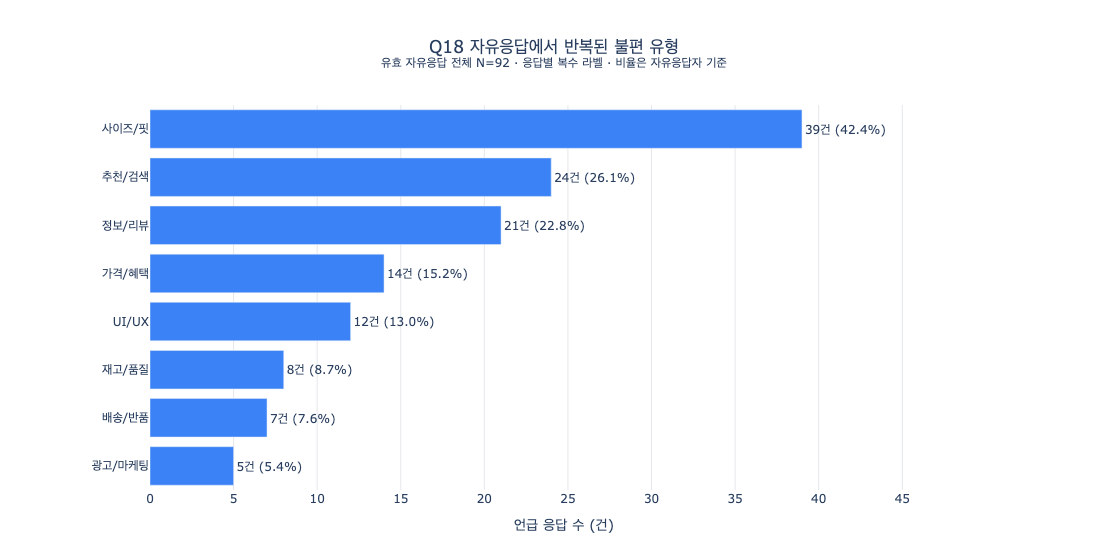

In [15]:
# 카테고리 막대를 전체 유효 자유응답 92건 기준으로 표시
fig = go.Figure(go.Bar(
    x=q18_types.values,
    y=q18_types.index,
    orientation='h',
    marker_color=COLORS['view'],
    text=[f'{count}건 ({count/q18_n:.1%})' for count in q18_types.values],
    textposition='outside',
    cliponaxis=False,
    hovertemplate='%{y}<br>%{text}<extra></extra>',
))
fig.update_xaxes(title_text='언급 응답 수 (건)',
                 range=[0, q18_types.max() * 1.27], gridcolor='#E5E7EB')
fig.update_yaxes(autorange='reversed')
fig.update_layout(
    title=dict(text=f'Q18 자유응답에서 반복된 불편 유형<br><sup>유효 자유응답 전체 N={q18_n} · 응답별 복수 라벨 · 비율은 자유응답자 기준</sup>', x=0.5),
    paper_bgcolor='white', plot_bgcolor='white',
    height=560, width=1000, margin=dict(l=150, r=130, t=105, b=70),
    showlegend=False,
)
fig.show()

### 성별 세부 비교 · Q18

각 유형을 언급한 사람을 해당 성별의 **유효 Q18 자유응답자 수**로 나눈다. 한 응답이 여러 불편 유형에 포함될 수 있다.

,성별,Q18 유형,n/N · %
0,남성,사이즈/핏,20/47 · 42.6%
1,남성,추천/검색,12/47 · 25.5%
2,남성,정보/리뷰,5/47 · 10.6%
3,남성,가격/혜택,8/47 · 17.0%
4,남성,UI/UX,10/47 · 21.3%
5,남성,재고/품질,4/47 · 8.5%
6,남성,배송/반품,3/47 · 6.4%
7,남성,광고/마케팅,1/47 · 2.1%
8,여성,사이즈/핏,19/45 · 42.2%
9,여성,추천/검색,12/45 · 26.7%


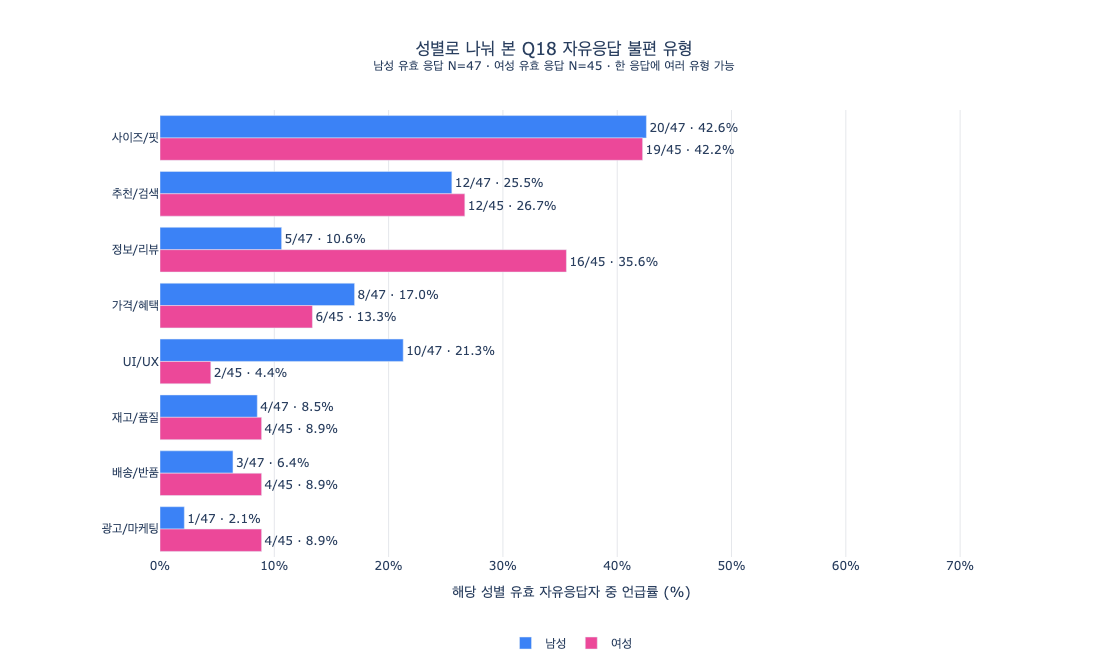

In [16]:
q18_gender_n = q18_gender.groupby('gender')['user_id'].nunique().reindex(GENDERS)
q18_categories = q18_table.index.tolist()
q18_rows = []
for gender in GENDERS:
    denominator = int(q18_gender_n[gender])
    for category in q18_categories:
        mentioned = q18_gender.loc[
            q18_gender['gender'].eq(gender)
            & q18_gender['category'].eq(category), 'user_id'
        ].nunique()
        q18_rows.append([gender, category, mentioned, denominator,
                         mentioned / denominator * 100, n_n_pct(mentioned, denominator)])
q18_gender_table = pd.DataFrame(q18_rows, columns=['성별', 'Q18 유형', '언급자', '성별 N', '언급률(%)', 'n/N · %'])
assert q18_gender_table.groupby('Q18 유형')['언급자'].sum().reindex(q18_categories).tolist() == q18_types.reindex(q18_categories).tolist()
assert int(q18_gender_n.sum()) == q18_n == 92
display(q18_gender_table[['성별', 'Q18 유형', 'n/N · %']])

fig = go.Figure()
for gender in GENDERS:
    part = q18_gender_table.loc[q18_gender_table['성별'].eq(gender)].set_index('Q18 유형').reindex(q18_categories)
    fig.add_trace(go.Bar(
        y=q18_categories, x=part['언급률(%)'], orientation='h', name=gender,
        marker_color=GENDER_COLORS[gender], text=part['n/N · %'], textposition='outside',
        customdata=part['n/N · %'],
        hovertemplate='%{y}<br>' + gender + ' %{customdata}<extra></extra>',
    ))
fig.update_layout(
    barmode='group',
    title=dict(text=f'성별로 나눠 본 Q18 자유응답 불편 유형<br><sup>남성 유효 응답 N={int(q18_gender_n["남성"])} · 여성 유효 응답 N={int(q18_gender_n["여성"])} · 한 응답에 여러 유형 가능</sup>', x=0.5),
    xaxis=dict(title='해당 성별 유효 자유응답자 중 언급률 (%)', range=[0, 72], gridcolor='#E5E7EB', ticksuffix='%'),
    yaxis=dict(autorange='reversed'),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.16),
    height=670, width=1120, margin=dict(l=160, r=125, t=110, b=85),
)
fig.show()

사이즈·핏 언급률은 남성 42.6%, 여성 42.2%로 비슷했다. 정보·리뷰는 여성 35.6%, 남성 10.6%였지만, 자발적으로 답한 92건 안에서의 탐색적 비교다.

### 후속 탐색 결과

선택형 Q13에서는 플랫폼 사용자 200명 중 102명(51.0%)이 사이즈 문제를 선택했다. 자유응답 Q18에서도 사이즈·핏이 유효 응답 92건 중 39건(42.4%)으로 가장 많이 언급됐고, 플랫폼 사용자 응답에서는 28/68건(41.2%)에서 나타났다.

성별로 나누면 Q13의 사진과 실물 차이 선택률은 여성 52.1%, 남성 31.6%였다. Q18의 정보·리뷰 언급률도 여성 35.6%, 남성 10.6%로 관찰됐다. Q18 사이즈·핏 언급률은 남성 42.6%, 여성 42.2%로 비슷했다. 성별 선택률은 플랫폼 사용자, 성별 언급률은 유효 자유응답자를 각각 분모로 계산했다.

사이즈·핏은 질문 방식과 분모가 다른 두 문항에서 반복적으로 나타나 **후속 UX 검증 후보**로 좁혔다.

### 설문 설계 회고

자유응답에는 Q13 선택지 밖의 추천·검색, 가격·혜택, UI·UX 등의 주제도 있었다. 향후 설문을 설계할 때 문항 범위를 점검할 수 있다.

---
## 6. 분석 범위와 활용 방향

### 분석 범위

이 설문은 20대 비중이 높은 편의표본으로 여러 패션 플랫폼 이용자의 응답을 모았다. Q14는 가장 자주 사용하는 플랫폼에 대한 미래 이용 의향, Q15는 현재 사용하는 패션 플랫폼에 대한 추천 의향을 측정했다. 가설 1의 병합 교차표에서 기대빈도 5 미만인 셀은 1개였다.

가설 2는 최근 6개월 구매자 191명의 자기보고 구매 빈도·최근성을 기준으로 했다. 플랫폼 사용자 200명 중 9명은 최근 6개월 비구매자였다. Q9·Q10은 패션 플랫폼 구매 전반의 활동을 물었다.

Q16·Q17은 각각 최초 인지 경로와 최근 구매 영향 채널을 회상해 답한 문항이다. 가설 3은 공통 3채널 인지자 155명에서 두 응답의 연결을 분석했다. Q13은 플랫폼 사용자 200명의 선택형 응답, Q18은 자발적 유효 자유응답 92건(그중 플랫폼 사용자 68건)을 기준으로 했다. 각 문항의 비율은 해당 응답자 집단을 분모로 계산했다.

### 활용 방향

**추천 의향·이용·구매:** 추천 의향은 지속 이용 의향과 양의 관계였지만 비추천자 중에도 87.5%가 긍정 지속 의향을 답했고, 자기보고 구매 활동과의 관계는 약했다. 특정 플랫폼에서 같은 설문 응답과 재방문·구매·실제 잔류 또는 이탈 로그를 연결해 이 태도 차이가 행동에서도 나타나는지 확인한다.

**채널:** 최초 인지 채널별 동일 채널 응답률은 SNS·유튜브와 친구/지인에서 달랐다. 특정 서비스의 최초 유입 경로, 재방문 경로, 구매 직전 접점과 실제 구매를 연결해 인지와 구매 과정에서 각 채널의 역할을 확인한다.

**사이즈·핏:** Q13과 Q18에서 반복된 불편을 상품군별로 다시 확인한다. 상품 상세 조회→장바구니→구매와 사이즈 사유 반품·교환, 재구매를 연결해 실제 행동에서도 같은 문제가 나타나는 영역을 좁힌 뒤 UX 개선 대상을 구체화한다.